# Multi-Channel Marketing Attribution - Exploratory Data Analysis (EDA)

In this notebook, we explore the `raw_data.csv` dataset to understand user interactions across different marketing channels and their impact on conversions.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset

In [3]:
try:
    df = pd.read_csv('../data/raw_data.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: ../data/raw_data.csv not found. Please ensure the data file is placed in the 'data' folder.")

Dataset loaded successfully.


,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


## 3. Dataset Overview and Missing Values

In [4]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe(include='all'))

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     10000 non-null  int64 
 1   Timestamp   10000 non-null  object
 2   Channel     10000 non-null  object
 3   Campaign    10000 non-null  object
 4   Conversion  10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB

--- Missing Values ---


User ID       0
Timestamp     0
Channel       0
Campaign      0
Conversion    0
dtype: int64


--- Descriptive Statistics ---


,User ID,Timestamp,Channel,Campaign,Conversion
count,10000.00000,10000,10000,10000,10000
unique,NaN,9737,6,6,2
top,NaN,2025-02-11 09:45:49,Direct Traffic,-,No
freq,NaN,3,1721,3131,5056
mean,54957.01700,NaN,NaN,NaN,NaN
std,25685.14741,NaN,NaN,NaN,NaN
min,10028.00000,NaN,NaN,NaN,NaN
25%,32391.00000,NaN,NaN,NaN,NaN
50%,55446.00000,NaN,NaN,NaN,NaN
75%,77298.00000,NaN,NaN,NaN,NaN


## 4. Channel Distribution

/tmp/ipykernel_38/1958741794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Channel', order=df['Channel'].value_counts().index, palette='viridis')


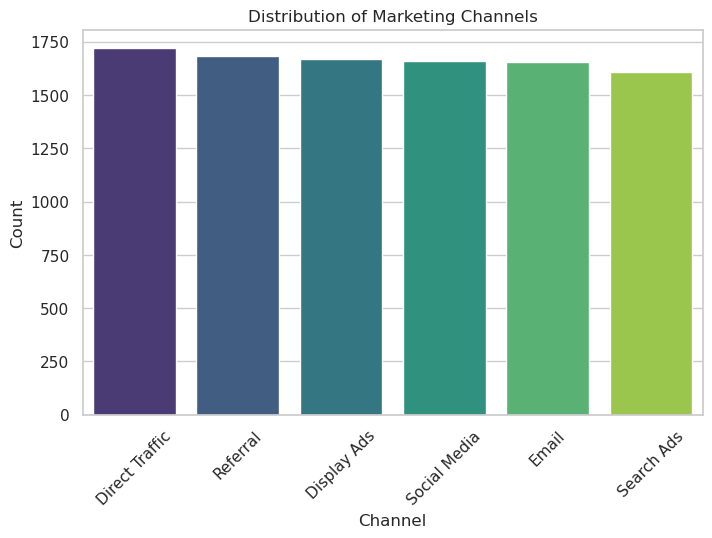

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Channel', order=df['Channel'].value_counts().index, palette='viridis')
plt.title('Distribution of Marketing Channels')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 5. Conversion Rate per Channel
We need to be careful here: `Conversion` is often marked as 'Yes' or 'No', or 1/0.

/tmp/ipykernel_38/3080436617.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conv_rate, x='Channel', y='Conversion', palette='magma')


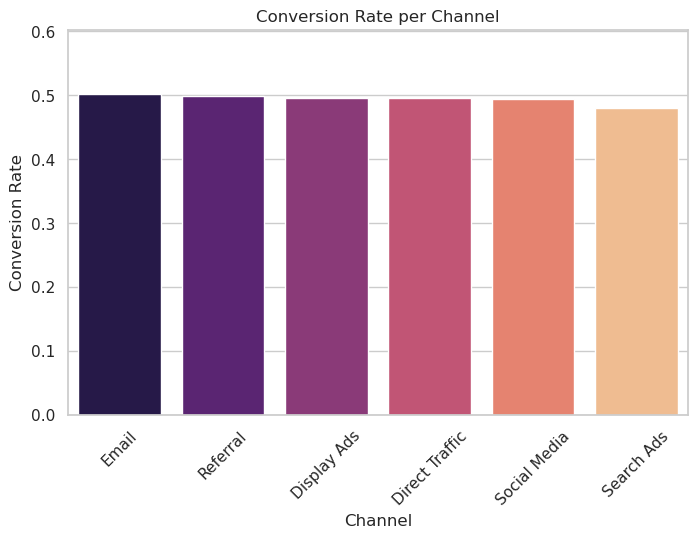

In [6]:
# Convert 'Conversion' to integer if it's 'Yes'/'No'
if df['Conversion'].dtype == 'object':
    df['Conversion'] = df['Conversion'].map({'Yes': 1, 'No': 0})

# Calculate conversion rate per channel
conv_rate = df.groupby('Channel')['Conversion'].mean().reset_index().sort_values(by='Conversion', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=conv_rate, x='Channel', y='Conversion', palette='magma')
plt.title('Conversion Rate per Channel')
plt.xlabel('Channel')
plt.ylabel('Conversion Rate')
plt.ylim(0, max(conv_rate['Conversion']) * 1.2)
plt.xticks(rotation=45)
plt.show()

## 6. Time-based Interaction Analysis
Let's see how interactions vary by day of the week or hour.

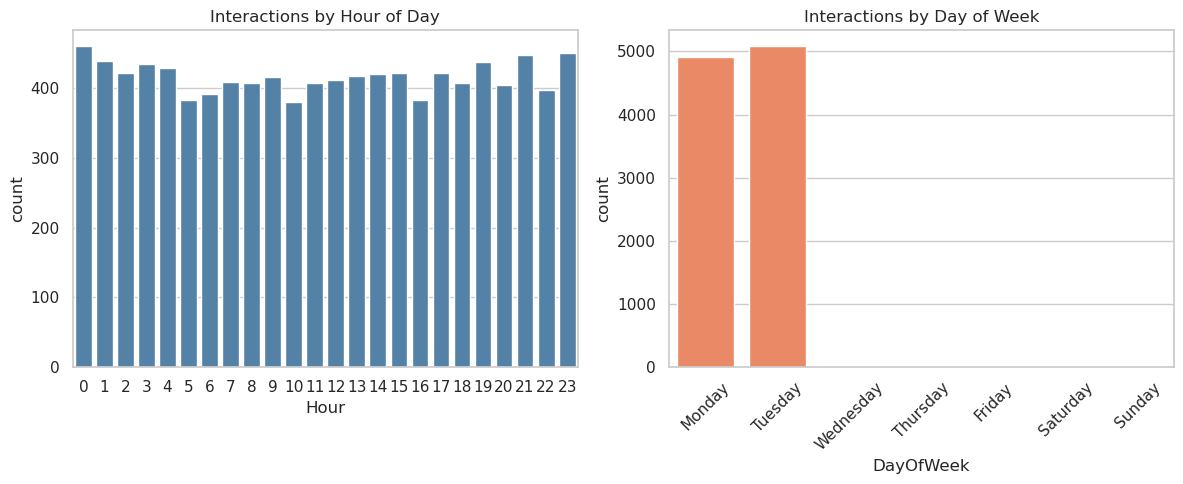

In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Hour', color='steelblue')
plt.title('Interactions by Hour of Day')

plt.subplot(1, 2, 2)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=days_order, color='coral')
plt.title('Interactions by Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()